# Consultas – Redis
Dataset: *eCommerce Purchase History from Electronics Store*

**Estrategia de almacenamiento:**
- `HASH  order:<id>` → campos del pedido
- `ZSET  sales:by_category` → score = cantidad de ventas
- `ZSET  revenue:by_brand`  → score = ingresos acumulados
- `ZSET  sales:by_month`    → score = cantidad de ventas

**Consultas:** categoría más vendida · marca con más ingresos · mes con más ventas (UTC)

In [1]:
import redis
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

r = redis.Redis(host='localhost', port=6379, decode_responses=True)
print(f'Conexión exitosa. Total claves: {r.dbsize():,}')

Conexión exitosa. Total claves: 1,435,269


## Q1 – Categoría más vendida

Tiempo de respuesta: 0.001919s


,category,count
0,nan,614198
1,electronics.smartphone,359490
2,appliances.kitchen.refrigerators,77599
3,16.18,72969
4,electronics.video.tv,71948
5,computers.notebook,71764
6,electronics.audio.headphone,66831
7,appliances.environment.vacuum,66756
8,appliances.kitchen.kettle,62956
9,appliances.kitchen.washer,56411


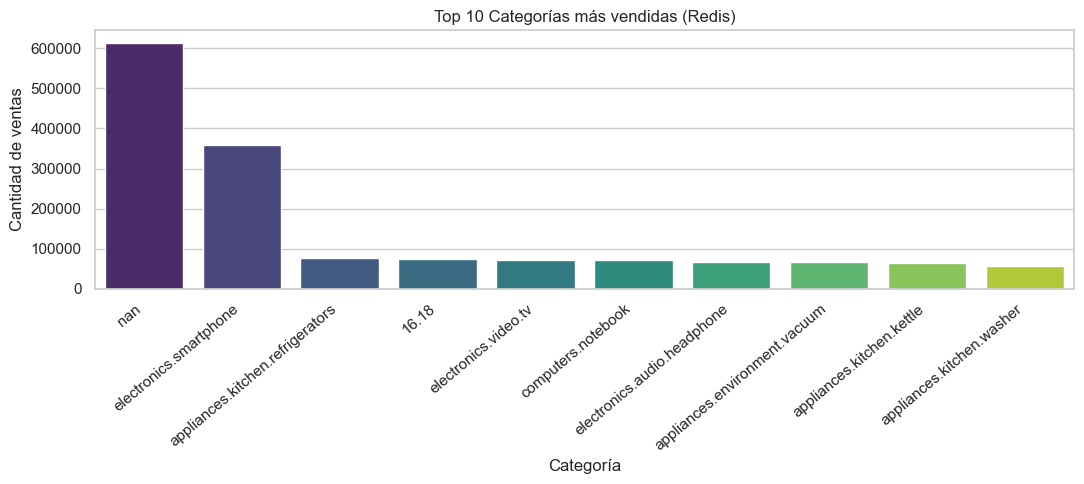

In [2]:
t0 = time.time()
raw_q1 = r.zrevrange('sales:by_category', 0, 9, withscores=True)
elapsed_q1 = time.time() - t0

df_q1 = pd.DataFrame(raw_q1, columns=['category', 'count'])
df_q1['count'] = df_q1['count'].astype(int)
print(f'Tiempo de respuesta: {elapsed_q1:.6f}s')
display(df_q1)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=df_q1, x='category', y='count', hue='category', palette='viridis', legend=False, ax=ax)
ax.set_title('Top 10 Categorías más vendidas (Redis)')
ax.set_xlabel('Categoría')
ax.set_ylabel('Cantidad de ventas')
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.show()


## Q2 – Marca con más ingresos brutos

Tiempo de respuesta: 0.001747s


,brand,revenue_usd
0,samsung,90501736.57
1,apple,48195793.24
2,lg,26251122.01
3,bosch,11106462.88
4,huawei,10831409.26
5,asus,10688302.12
6,lenovo,10569681.07
7,ava,8571159.75
8,beko,8524158.09
9,oppo,7340557.16


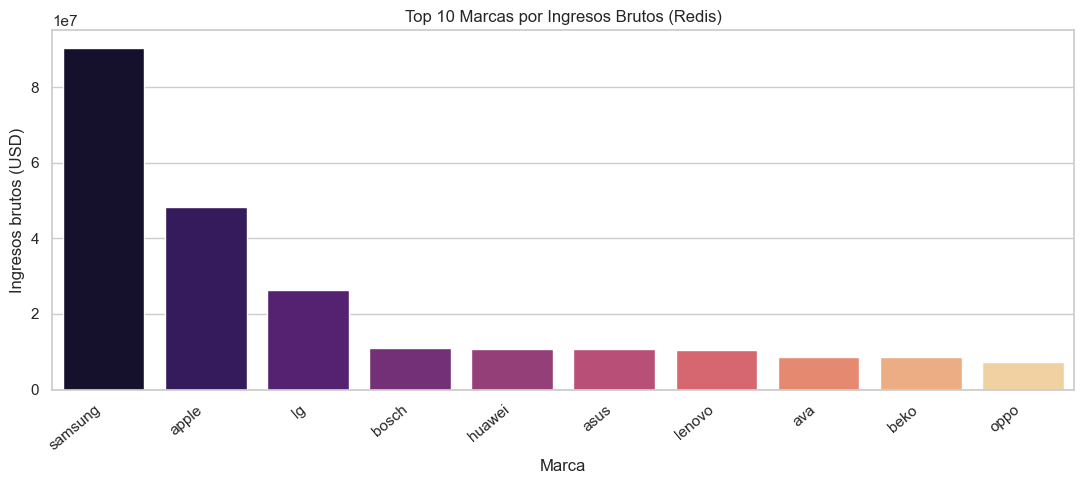

In [3]:
t0 = time.time()
raw_q2 = r.zrevrange('revenue:by_brand', 0, 9, withscores=True)
elapsed_q2 = time.time() - t0

df_q2 = pd.DataFrame(raw_q2, columns=['brand', 'revenue_usd'])
df_q2['revenue_usd'] = df_q2['revenue_usd'].round(2)
print(f'Tiempo de respuesta: {elapsed_q2:.6f}s')
display(df_q2)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=df_q2, x='brand', y='revenue_usd', hue='brand', palette='magma', legend=False, ax=ax)
ax.set_title('Top 10 Marcas por Ingresos Brutos (Redis)')
ax.set_xlabel('Marca')
ax.set_ylabel('Ingresos brutos (USD)')
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.show()


## Q3 – Mes con más ventas (UTC)

Tiempo de respuesta: 0.001606s


,month,count
11,1970-01,19631
5,2020-01,266045
2,2020-02,323272
3,2020-03,314510
10,2020-04,58780
6,2020-05,233436
0,2020-06,403632
7,2020-07,167080
4,2020-08,301188
1,2020-09,361977


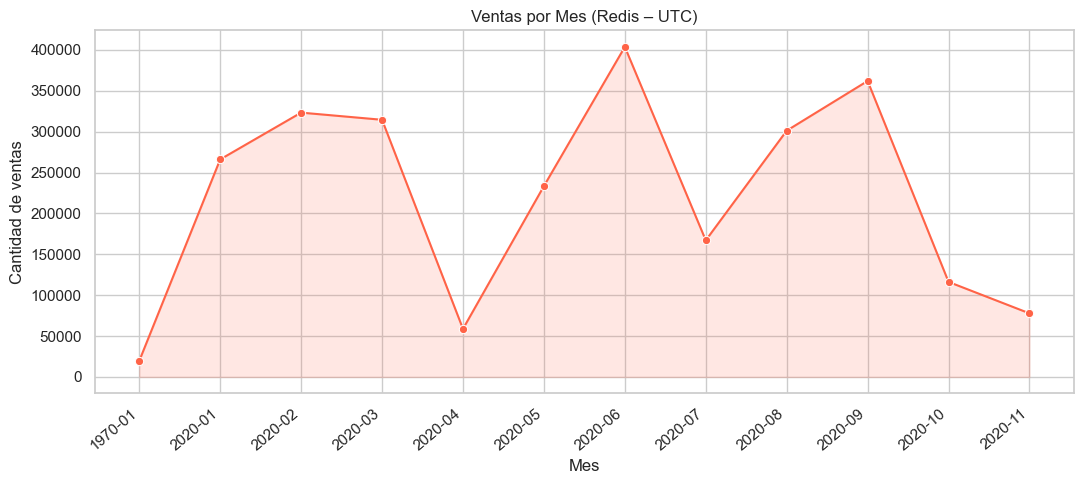

In [4]:
t0 = time.time()
raw_q3 = r.zrevrange('sales:by_month', 0, -1, withscores=True)
elapsed_q3 = time.time() - t0

df_q3 = pd.DataFrame(raw_q3, columns=['month', 'count'])
df_q3['count'] = df_q3['count'].astype(int)
df_q3 = df_q3.sort_values('month')
print(f'Tiempo de respuesta: {elapsed_q3:.6f}s')
display(df_q3)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=df_q3, x='month', y='count', marker='o', color='tomato', ax=ax)
ax.fill_between(df_q3['month'], df_q3['count'], alpha=0.15, color='tomato')
ax.set_title('Ventas por Mes (Redis – UTC)')
ax.set_xlabel('Mes')
ax.set_ylabel('Cantidad de ventas')
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.show()


## Resumen de tiempos de respuesta

,consulta,tiempo_s
0,Q1 – Categoría más vendida,0.001919
1,Q2 – Marca con más ingresos,0.001747
2,Q3 – Mes con más ventas,0.001606


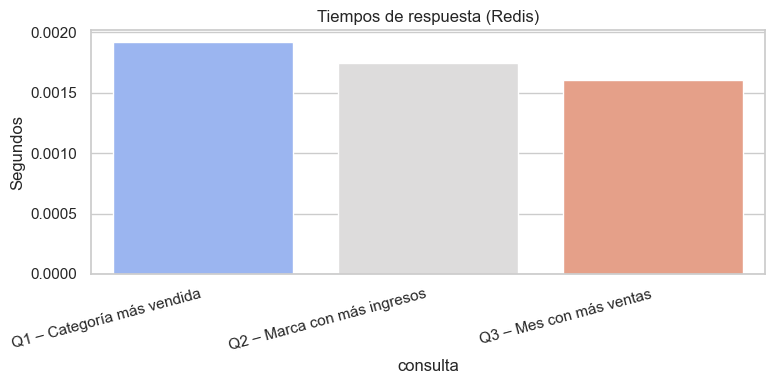

In [5]:
tiempos = pd.DataFrame({
    'consulta': ['Q1 – Categoría más vendida', 'Q2 – Marca con más ingresos', 'Q3 – Mes con más ventas'],
    'tiempo_s': [elapsed_q1, elapsed_q2, elapsed_q3]
})
display(tiempos)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=tiempos, x='consulta', y='tiempo_s', hue='consulta', palette='coolwarm', legend=False, ax=ax)
ax.set_title('Tiempos de respuesta (Redis)')
ax.set_ylabel('Segundos')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()
